# 1. File handling: persist data without losing its meaning

Learn to locate a file with a relative path, write and read UTF-8 text, manage open handles, and use CSV and JSON parsers. You will check a small data round trip and preserve the original input. Prerequisite: [Modules and packages](../../../01_Python_Foundations/09_modules_and_packages.ipynb). Allow two to three hours. All examples use synthetic values and automatically cleaned temporary directories inside the project; no existing dataset is overwritten.

## 2. What problem does this solve?

Notebook variables disappear when the kernel stops. Files let data and results survive beyond one Python process. A saved table can be shared with another program, inspected later, or used to reproduce an experiment. Persistence is useful only when we can interpret the saved bytes correctly.

A file does not explain its own observation unit, measurement units, or missing-value policy. A CSV containing `4` might mean four minutes or four hours. A reproducible workflow therefore needs both file operations and a data contract: field names, types, units, row meaning, and provenance.

## 3. Intuition and analogy

Think of a file as a sealed envelope containing bytes. The path tells you which envelope to open. An encoding explains how those bytes represent text. A parser explains how that text represents records. Reading the envelope successfully does not prove its contents satisfy the expected schema.

An open file handle is like borrowing a key to the envelope cabinet. The key should be returned even if reading fails. Python's `with` statement manages this lifetime: leaving the block closes the handle whether execution finishes normally or raises an exception.

## 4. Terminology

A **path** identifies a filesystem location. A **relative path** is interpreted from a starting directory; an **absolute path** identifies a location independently of the current directory. The **working directory** is the starting point for ordinary relative paths. `pathlib.Path` represents paths using portable operations rather than manually assembling Windows separators.

**Text mode** decodes bytes into strings using an encoding; **binary mode** reads or writes bytes directly. **UTF-8** is a widely used text encoding. A **file handle** is the open object used for I/O. **CSV** stores delimited tabular fields with quoting rules. **JSON** stores structured values such as objects, lists, numbers, and strings. A **round trip** saves data and loads it back to verify preservation under the chosen format.

## 5. Mathematical foundations

Three visits have waiting times $x_1=2$, $x_2=4$, and $x_3=6$ minutes. Their average is

$$\bar x=\frac{x_1+x_2+x_3}{n},\qquad n=3.$$

Each $x_i$ is a scalar measurement for one visit. The loaded numerical sequence has length three, and the output is one scalar in minutes. The file may store these values as characters, but the mathematical calculation requires numerical values after parsing.

For a faithful round trip, record identity, units, and values should be preserved. Equality of the final mean alone is too weak: two different datasets can share the same mean. We will therefore compare the individual loaded values and the full structured records as well.

## 6. Hand-calculated example

The text `2`, `4`, and `6` on three separate lines represents three values under our declared one-number-per-line format. Add them to get twelve and divide by three to obtain four minutes. If the line `6` were accidentally lost, the mean would become three. If the lines were reordered, the mean would remain four but observation order would change.

A CSV version adds visit IDs so that values can be tied to their records. A JSON summary stores the mean, count, and unit explicitly. Neither representation is automatically correct; the contract determines which fields must be checked.

## 7. Plain-text implementation from scratch

In [1]:
# Enable embedded figures in this fresh notebook kernel.
from IPython import get_ipython
get_ipython().run_line_magic('matplotlib', 'inline')

In [2]:
from pathlib import Path
from tempfile import TemporaryDirectory

project_root = Path.cwd()
if not (project_root / 'lesson_sources').is_dir():
    project_root = project_root.parent
artifact_dir = project_root / 'artifacts'
artifact_dir.mkdir(exist_ok=True)

with TemporaryDirectory(prefix='file-lesson-', dir=artifact_dir) as temporary:
    scratch = Path(temporary)
    text_path = scratch / 'waits.txt'
    text_path.write_text('2\n4\n6\n', encoding='utf-8')
    original_bytes = text_path.read_bytes()
    loaded_values = []
    with text_path.open('r', encoding='utf-8') as handle:
        for line in handle:
            loaded_values.append(float(line.strip()))
    assert handle.closed
    assert loaded_values == [2.0, 4.0, 6.0]
    assert text_path.read_bytes() == original_bytes
    mean_wait = sum(loaded_values) / len(loaded_values)
    print('Loaded values:', loaded_values, 'Mean:', mean_wait, 'minutes')
    assert mean_wait == 4

assert not scratch.exists()

Loaded values: [2.0, 4.0, 6.0] Mean: 4.0 minutes


The file-reading `with` closes the handle; the outer temporary-directory `with` cleans up the disposable files afterward. The loaded values remain ordinary Python objects in memory. We do not try to reuse a deleted temporary path in a later cell.

## 8. Step-by-step inspection and modes

`'r'` reads an existing file. `'w'` creates or truncates a file, so it can destroy previous contents. `'a'` appends, which can duplicate rows when a notebook is rerun. `'x'` creates a new file only and fails if it already exists. Choose a mode based on whether replacement is intended.

In [3]:
with TemporaryDirectory(prefix='file-mode-', dir=artifact_dir) as temporary:
    path = Path(temporary) / 'new_result.txt'
    with path.open('x', encoding='utf-8') as handle:
        handle.write('mean_wait_minutes=4\n')
    before = path.read_bytes()
    try:
        with path.open('x', encoding='utf-8') as handle:
            handle.write('unwanted replacement')
    except FileExistsError:
        print('Exclusive creation prevented accidental replacement.')
    else:
        raise AssertionError('Existing file unexpectedly replaced')
    assert path.read_bytes() == before

Exclusive creation prevented accidental replacement.


This is an expected failure with a specific recovery policy: retain the first file. It is not permission to catch every filesystem error or silently ignore a failed save.

## 9. CSV and JSON library implementation

CSV requires a parser because quoted fields may contain commas. On Windows, `newline=''` lets the csv module manage newline conventions. Explicit UTF-8 avoids relying on a machine's default encoding.

In [4]:
import csv
import json

records = [{'visit_id': 1, 'wait_minutes': 2, 'site': 'North, desk A'},
           {'visit_id': 2, 'wait_minutes': 4, 'site': 'North, desk A'},
           {'visit_id': 3, 'wait_minutes': 6, 'site': 'South'}]
with TemporaryDirectory(prefix='structured-files-', dir=artifact_dir) as temporary:
    csv_path = Path(temporary) / 'visits.csv'
    with csv_path.open('w', encoding='utf-8', newline='') as handle:
        writer = csv.DictWriter(handle, fieldnames=['visit_id', 'wait_minutes', 'site'])
        writer.writeheader()
        writer.writerows(records)
    with csv_path.open('r', encoding='utf-8', newline='') as handle:
        raw_rows = list(csv.DictReader(handle))
    restored = [{'visit_id': int(row['visit_id']), 'wait_minutes': int(row['wait_minutes']),
                 'site': row['site']} for row in raw_rows]
    assert restored == records
    summary = {'count': len(restored), 'mean_wait': 4.0, 'unit': 'minutes', 'synthetic': True}
    json_path = Path(temporary) / 'summary.json'
    json_path.write_text(json.dumps(summary, ensure_ascii=False, allow_nan=False), encoding='utf-8')
    restored_summary = json.loads(json_path.read_text(encoding='utf-8'))
    assert restored_summary == summary
    print('CSV record preserved:', restored[0])
    print('JSON summary:', restored_summary)

CSV record preserved: {'visit_id': 1, 'wait_minutes': 2, 'site': 'North, desk A'}
JSON summary: {'count': 3, 'mean_wait': 4.0, 'unit': 'minutes', 'synthetic': True}


CSV fields load as strings here, so numerical conversion is explicit. JSON preserves the basic numeric and Boolean types used in this summary, but it does not represent every Python object type. `allow_nan=False` rejects nonstandard nonfinite values rather than emitting them into a supposedly portable JSON document.

## 10. Visualization

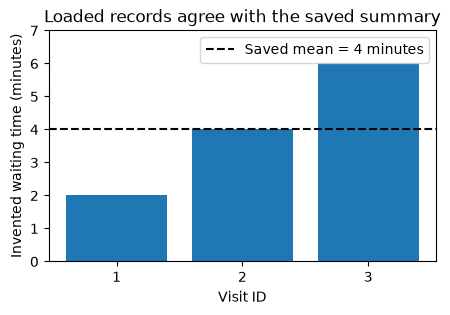

In [5]:
import matplotlib.pyplot as plt
from IPython.display import display
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar([str(row['visit_id']) for row in restored], [row['wait_minutes'] for row in restored])
ax.axhline(restored_summary['mean_wait'], color='black', linestyle='--', label='Saved mean = 4 minutes')
ax.set(xlabel='Visit ID', ylabel='Invented waiting time (minutes)', title='Loaded records agree with the saved summary', ylim=(0, 7))
ax.legend()
display(fig)
plt.close(fig)

The plot is generated from loaded records, not a separately typed copy of the original measurements. It supports the round-trip check but is not a substitute for exact record comparison. A changed order or duplicated ID can be hard to notice in a small chart.

## 11. Realistic experiment: malformed records

Data can be readable text while violating its declared schema. A missing quantity, duplicate ID, or unrecognized unit needs diagnosis. This small example checks the schema without pretending that `float` alone validates the business meaning.

In [6]:
from io import StringIO
bad_csv = 'visit_id,wait_minutes\n1,2\n1,\n'
bad_rows = list(csv.DictReader(StringIO(bad_csv)))
ids = [row['visit_id'] for row in bad_rows]
missing = [row for row in bad_rows if row['wait_minutes'].strip() == '']
assert len(set(ids)) != len(ids)
assert len(missing) == 1
print('Diagnosed duplicate IDs and', len(missing), 'missing measurement; not silently filled.')

Diagnosed duplicate IDs and 1 missing measurement; not silently filled.


If you impute a missing value for later modeling, fit that rule using training data only. Keep raw input and a documented derived table so that readers can see what changed.

## 12. Format and path choices

Choose CSV for simple interoperable tables, JSON for small nested metadata, and plain text for explicitly simple formats. These are software choices, not learned model parameters. Keep paths relative to the repository's documented layout. A printed absolute temporary path is diagnostic output, not a machine-specific path embedded into lesson code.

## 13. Evaluation

Verify row count, unique IDs, individual values, type conversions, units, encoding, and unchanged raw bytes. Test empty, malformed, and quoted-field cases. Check that a saved output can actually be reopened. File existence alone does not prove a complete or valid save. Production systems may require atomic replacement and recovery procedures; our temporary examples do not claim those guarantees.

## 14. Assumptions and limitations

These tiny files fit in memory. Large files may need streaming, chunking, or a database. CSV does not inherently preserve types, and JSON does not inherently preserve arbitrary objects, tuples, or custom classes. Plain numerical lines are safe only because we declared a restricted format. Avoid loading untrusted executable serialization formats as if they were ordinary passive text.

## 15. Common mistakes and debugging

Do not assume the working directory equals the notebook's location in every launcher. Inspect it when a path fails. Avoid manually splitting CSV on commas. Do not append repeatedly without an idempotent plan. Do not overwrite raw data while cleaning it. If a decode fails, investigate the declared encoding rather than silently discarding characters.

## 16. Comparison with alternatives

`pathlib` handles locations; `csv` and `json` interpret formats. pandas offers convenient table loading and export, while NumPy offers numerical array formats. A database adds transactions, queries, and concurrent access rules. Select a tool based on structure, scale, and integrity requirements rather than filename fashion.

## 17. Exercises

1. **Beginner:** Explain why `'w'` and `'x'` differ when a file already exists.
2. **Beginner:** Compute the mean of values `[1,3,8]` before saving them.
3. **Beginner:** Name two pieces of metadata a list of bare numbers fails to communicate.
4. **Intermediate:** Explain why checking only the restored mean cannot prove every record survived a round trip.
5. **Intermediate:** Describe how quoted commas and Windows newline handling affect CSV writing and reading.
6. **Challenge:** Save and restore three complete synthetic records with UTF-8 text, preserve raw values and IDs, and refuse accidental replacement of the same output filename.

## 18. Detailed solutions

1. Write mode truncates the old contents; exclusive-create mode raises `FileExistsError` instead. A failed exclusive create leaves the existing file intact.
2. The total is twelve and count three, so the mean is four in the original measurement units.
3. Units and observation meaning are missing; source, dates, schema, and missing-data rules may also be needed.
4. `[2,4,6]` and `[1,4,7]` both average four. Compare full records, identities, and order where relevant, not only a summary.
5. CSV quoting lets a comma belong inside a field. Using the csv library with `newline=''` avoids competing newline translations on Windows.
6. Use a temporary directory, an explicit schema, UTF-8, and exclusive creation. This solution checks full structured equality, including a non-ASCII label.

In [7]:
exercise_records = [{'id': 1, 'label': 'café', 'value': 1},
                    {'id': 2, 'label': 'north', 'value': 3},
                    {'id': 3, 'label': 'south', 'value': 8}]
with TemporaryDirectory(prefix='file-exercise-', dir=artifact_dir) as temporary:
    destination = Path(temporary) / 'records.json'
    with destination.open('x', encoding='utf-8') as handle:
        json.dump(exercise_records, handle, ensure_ascii=False, allow_nan=False)
    restored_exercise = json.loads(destination.read_text(encoding='utf-8'))
    assert restored_exercise == exercise_records
    assert len({row['id'] for row in restored_exercise}) == 3
    try:
        with destination.open('x', encoding='utf-8'):
            pass
    except FileExistsError:
        print('Exercise round trip passed; existing output protected.')
    else:
        raise AssertionError('Accidental replacement allowed')

Exercise round trip passed; existing output protected.


## 19. Knowledge check

**What does a relative path depend on?** Its starting directory. **Why use with?** To release the file handle on normal and exceptional exits. **Does CSV preserve numeric types automatically?** Not with this basic parser. **Why specify UTF-8?** To make text interpretation explicit. **Does a saved file prove valid data?** No; schema and content still need checks.

## 20. Interview preparation

**Text versus binary mode?** Decoded strings versus raw bytes. **Why avoid raw-data overwrite?** It destroys provenance and makes transformations harder to audit. **What makes a strong round-trip test?** It checks meaningful identities, values, types, and metadata. **How handle a large file?** Stream or chunk with an explicit aggregation and integrity plan. **Why is file existence a weak success check?** A partial, empty, stale, or malformed file can exist without satisfying the output contract.

## 21. Summary and next steps

Persistence requires explicit paths, formats, lifetimes, and data contracts. Continue to [Exceptions and debugging](../../../01_Python_Foundations/11_exceptions_and_debugging.ipynb), where failures become evidence for diagnosing incorrect assumptions.